### SDSS Galaxies vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. (SDSS) 

This is one of the most famous example of machine-learning classification in astronomy. For some recent work see e.g. 
- *Identifying galaxies, quasars, and stars with machine learning: A new catalogue of classifications for 111 million SDSS sources without spectra* Clarke et al (2019) [arXiv:1909.10963](https://arxiv.org/abs/1909.10963)
- *Quasar and galaxy classification in Gaia Data Release 2* Bailer-Jones et al (2019) [arXiv:1910.05255](https://arxiv.org/abs/1910.05255)


SDSS observed in four bands:
    
![](https://speclite.readthedocs.io/en/latest/_images/sdss2010.png) 
    

In [83]:
import numpy as np
import pylab as plt
import pandas as pd

In [84]:
#Leggiamo il file
#Prendiamo anche i nomi
data=np.genfromtxt('galaxyquasar.csv', delimiter=',',names=True,usecols=(0,1,2,3,4,6),dtype=float,comments='#')
names = data.dtype.names
#Solo data
data=np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=(0,1,2,3,4,6),dtype=float)

#Creiamo array con i colori
d = dict(zip(names, data.T))

#Prendiamo i labels
labels = np.genfromtxt('galaxyquasar.csv', delimiter=',',skip_header=1,usecols=5,dtype=str)
print(labels)
#QSO = quasar
#galaxy...

set(labels) #estrae i valori unici da labels e li rende un set

['QSO' 'GALAXY' 'GALAXY' ... 'GALAXY' 'GALAXY' 'GALAXY']


{np.str_('GALAXY'), np.str_('QSO')}


#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [85]:
#Creiamo gli array per differenze di colori. Le magnitudini dei colori in sé dipendono dalla distanza dall'oggetto, mentre gli "indici colori"
#ovvero le differenze tra i colori sono legati alla forma dello spettro. Gli indici colore in questo caso rappresentano le features
#mentre i labels sono "Quasar" o "Galaxy"

#u (ultravioletto)
#g (verde) 
#r (rosso) 
#i (vicino infrarosso)
#z (infrarosso).
for diff in ['ug', 'gr', 'ri', 'iz']:
    d[diff]=d[diff[0]]-d[diff[1]] 
d['lab']=labels
d['nlab'] = np.where(d['lab'] == 'GALAXY', 0, 1)
n_samples = len(data)
#I colori ci aiuteranno a distinguere tra i due oggetti
#print(d)
print(d['nlab'])

[1 0 0 ... 0 0 0]


In [86]:
X=np.array([d['ug'], d['gr'], d['ri'], d['iz']]).T
y = np.array(d['nlab'],dtype=int) #stiamo cercando i quasar

In [87]:
import sklearn.model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier

In [88]:
#facciamo train_test splitting con 2/3 train e 1/3 test
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.33, random_state=42)

# Gaussian Naive Bayes

(0.9, 1.0)

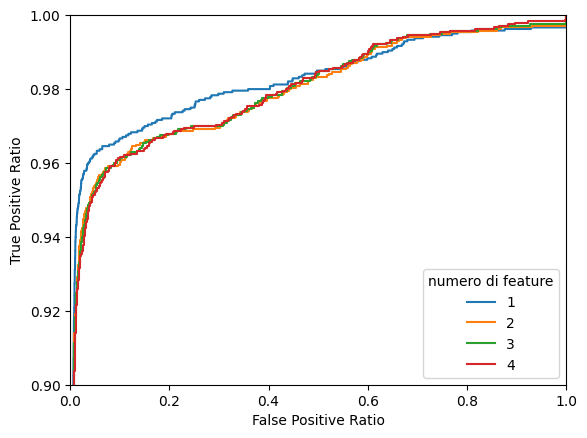

In [110]:
#Partiamo coi primi che abbiamo visto dunque Naive Bayes, in particolare Gaussian Naive Bayes

gnb = GaussianNB()
#aggiungiamo progressivamente nuove feature
for i in range(4):
    gnb.fit(X_train[:, 0:i+1], y_train)
    y_prob = gnb.predict_proba(X_test[:, 0:i+1])[:, 1] #to obtain the probability estimates for the test set (per feature che crescono)
    fpr, tpr, thresh = roc_curve(y_test, y_prob) #false positive rate, true positive rate, threshold, rispetto alla y_test conosciuta e quella "computata"
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend(title="numero di feature");
plt.xlim(0, 1.0)
plt.xlabel('False Positive Ratio')
plt.ylabel('True Positive Ratio')
plt.ylim(0.9, 1)

Il primo colore ovvero ug è sufficiente, la curve ROC raggiungono il FPR della curva ROC con solo la prima feature solo alla fine del grafico quando il TPR è attorno a 0.6, e comunque non scavallano la curva blu ma la raggiungono. Vediamo quali colori invalidano l'assunzione Naive

In [90]:
color_names = ['ug', 'gr', 'ri', 'iz']
df_features = pd.DataFrame(X, columns=color_names)
corr_matrix = df_features.corr()

print(corr_matrix)

          ug        gr        ri        iz
ug  1.000000  0.803315  0.469237  0.360335
gr  0.803315  1.000000  0.347712  0.318454
ri  0.469237  0.347712  1.000000 -0.158128
iz  0.360335  0.318454 -0.158128  1.000000


I colori che hanno covarianza che tende a 0 sono quelli che rispettano maggiormente l'ipotesi Naive, mentre vicino a 1 e -1 c'è correlazione
Ad esempio

ug-gr sono fortemente correlati dunque rompono l'assunzione Naive \
ri-iz sono quasi decorrelati, con -0.15 sono piuttosto vicini a 0

# Quadratic Discriminant Analysis
Togliamo l'ipotesi Naive di decorrelazione e di correlazione uguale in ogni feature e usiamo il QDA come metodo che tiene conto delle correlazioni tra le feature

(0.95, 1.0)

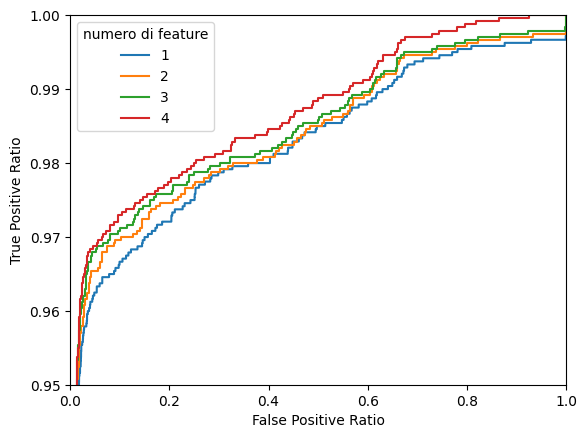

In [111]:
qda = QuadraticDiscriminantAnalysis()
#aggiungiamo progressivamente nuove feature
for i in range(4):
    qda.fit(X_train[:, 0:i+1], y_train)
    y_prob = qda.predict_proba(X_test[:, 0:i+1])[:, 1] #to obtain the probability estimates for the test set (per feature che crescono)
    fpr, tpr, thresh = roc_curve(y_test, y_prob) #false positive rate, true positive rate, threshold, rispetto alla y_test conosciuta e quella "computata"
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend(title="numero di feature");
plt.xlim(0, 1.0)
plt.xlabel('False Positive Ratio')
plt.ylabel('True Positive Ratio')
plt.ylim(0.95, 1)

Tenendo conto delle correlazioni tra le features, le ROC effettivamente migliorano con tutte le feature. Ogni nuova feature aiuta ad aggiungere informazione mentre col GNB gran parte dell'informazione trattata era ridondante

# Gaussian Mixture Model Bayes

Si usa la GMM per la distribuzione di densità dando K componenti scelte individualmente per le k feature. Possiamo scegliere K di componenti in modo uguale. Possiamo scegliere K "a mano", tramite cross-validation o con GridSearch

In [92]:
from sklearn.model_selection import GridSearchCV, KFold
param = {'n_components': [np.array([2]), np.array([3]), np.array([4]), np.array([5]), np.array([6])]}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=GMMBayes(), param_grid=param, cv=cv,n_jobs=-1)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GMMBayes(n_co...ts=array([1]))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_components': [array([2]), array([3]), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [93]:
best_K = grid_search.best_params_['n_components']
print(best_K)

[6]


(0.95, 1.0)

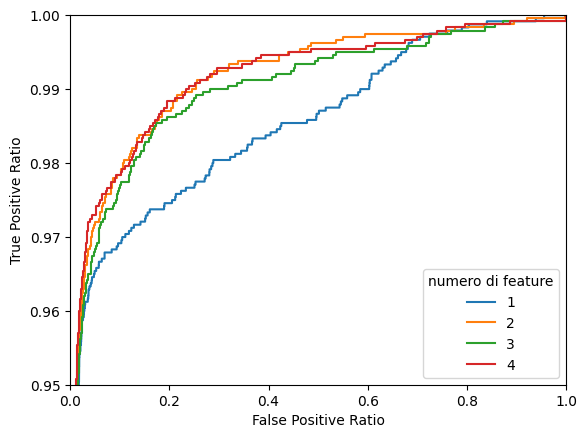

In [112]:
gmmb = GMMBayes(best_K)

for i in range(4):
    gmmb.fit(X_train[:, 0:i+1], y_train)
    y_prob = gmmb.predict_proba(X_test[:, 0:i+1])[:, 1] #to obtain the probability estimates for the test set (per feature che crescono)
    fpr, tpr, thresh = roc_curve(y_test, y_prob) #false positive rate, true positive rate, threshold, rispetto alla y_test conosciuta e quella "computata"
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend(title="numero di feature");
plt.xlim(0, 1.0)
plt.xlabel('False Positive Ratio')
plt.ylabel('True Positive Ratio')
plt.ylim(0.95, 1)

# K-Nearest Neighbours 

In [95]:
param = {'n_neighbors': [1,2,3,4,5,6,7,8,9]}
knc=KNeighborsClassifier()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=knc, param_grid=param, cv=cv,n_jobs=-1)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [96]:
best_nn = grid_search.best_params_['n_neighbors']
print(best_nn)

8


(0.95, 1.0)

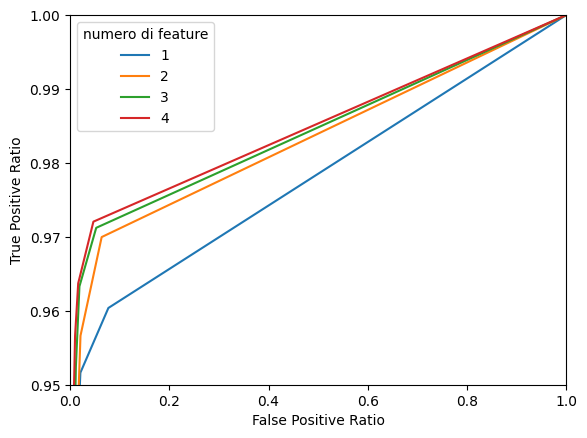

In [113]:
knc = KNeighborsClassifier(best_nn)

for i in range(4):
    knc.fit(X_train[:, 0:i+1], y_train)
    y_prob = knc.predict_proba(X_test[:, 0:i+1])[:, 1] #to obtain the probability estimates for the test set (per feature che crescono)
    fpr, tpr, thresh = roc_curve(y_test, y_prob) #false positive rate, true positive rate, threshold, rispetto alla y_test conosciuta e quella "computata"
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend(title="numero di feature");
plt.xlim(0, 1.0)
plt.xlabel('False Positive Ratio')
plt.ylabel('True Positive Ratio')
plt.ylim(0.95, 1)

(0.0, 3.0)

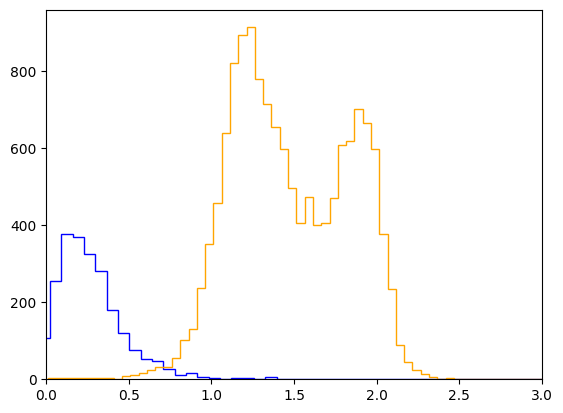

In [109]:
gmmb = GMMBayes(best_K)

#Trainiamo il modello su X_train e poi predictiamo su X_test, trovando y_pred

gmmb.fit(X_train[:, 0:4], y_train)
y_pred = gmmb.predict(X_test)
ug_test = X_test[:, 0]
plt.hist(ug_test[y_pred == 1], bins='auto', histtype='step', color='blue', label='Quasar')
plt.hist(ug_test[y_pred == 0], bins='auto', histtype='step', color='orange', label='Galaxy')
plt.xlim(0,3)

